In [1]:
import os.path as op
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

In [5]:
all_bursts = {
    'subject_id': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0, 156)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])

In [9]:
burst_idx = (all_bursts['group']=='TD') & (all_bursts['cluster']=='contra')

In [10]:
for key in all_bursts.keys():
    if key=='waveform_times':
        continue
    elif key=='waveform':
        all_bursts[key] = all_bursts[key][burst_idx,:]
    else:
        all_bursts[key] = all_bursts[key][burst_idx]

In [11]:
stim_idx = all_bursts['epoch_type']=='STIM'
resp_idx = all_bursts['epoch_type']=='RESP'

In [12]:
waveform_times=all_bursts['waveform_times']

In [15]:
n=len(np.unique(all_bursts['subject_id']))
print(f'N subjects={n}')

N subjects=33


In [16]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
#     waveforms_scaled = RobustScaler().fit_transform(waveforms)
    waveforms_scaled=np.zeros(waveforms.shape)
    for subject in np.unique(all_bursts['subject_id']):
        s_idx=all_bursts['subject_id']==subject
        waveforms_scaled[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
    waveforms_scaled = RobustScaler().fit_transform(waveforms_scaled)


    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

shuffling_results=get_num_components(all_bursts['waveform'], 20)
print(f'Non-noise PCs: {shuffling_results}')

Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


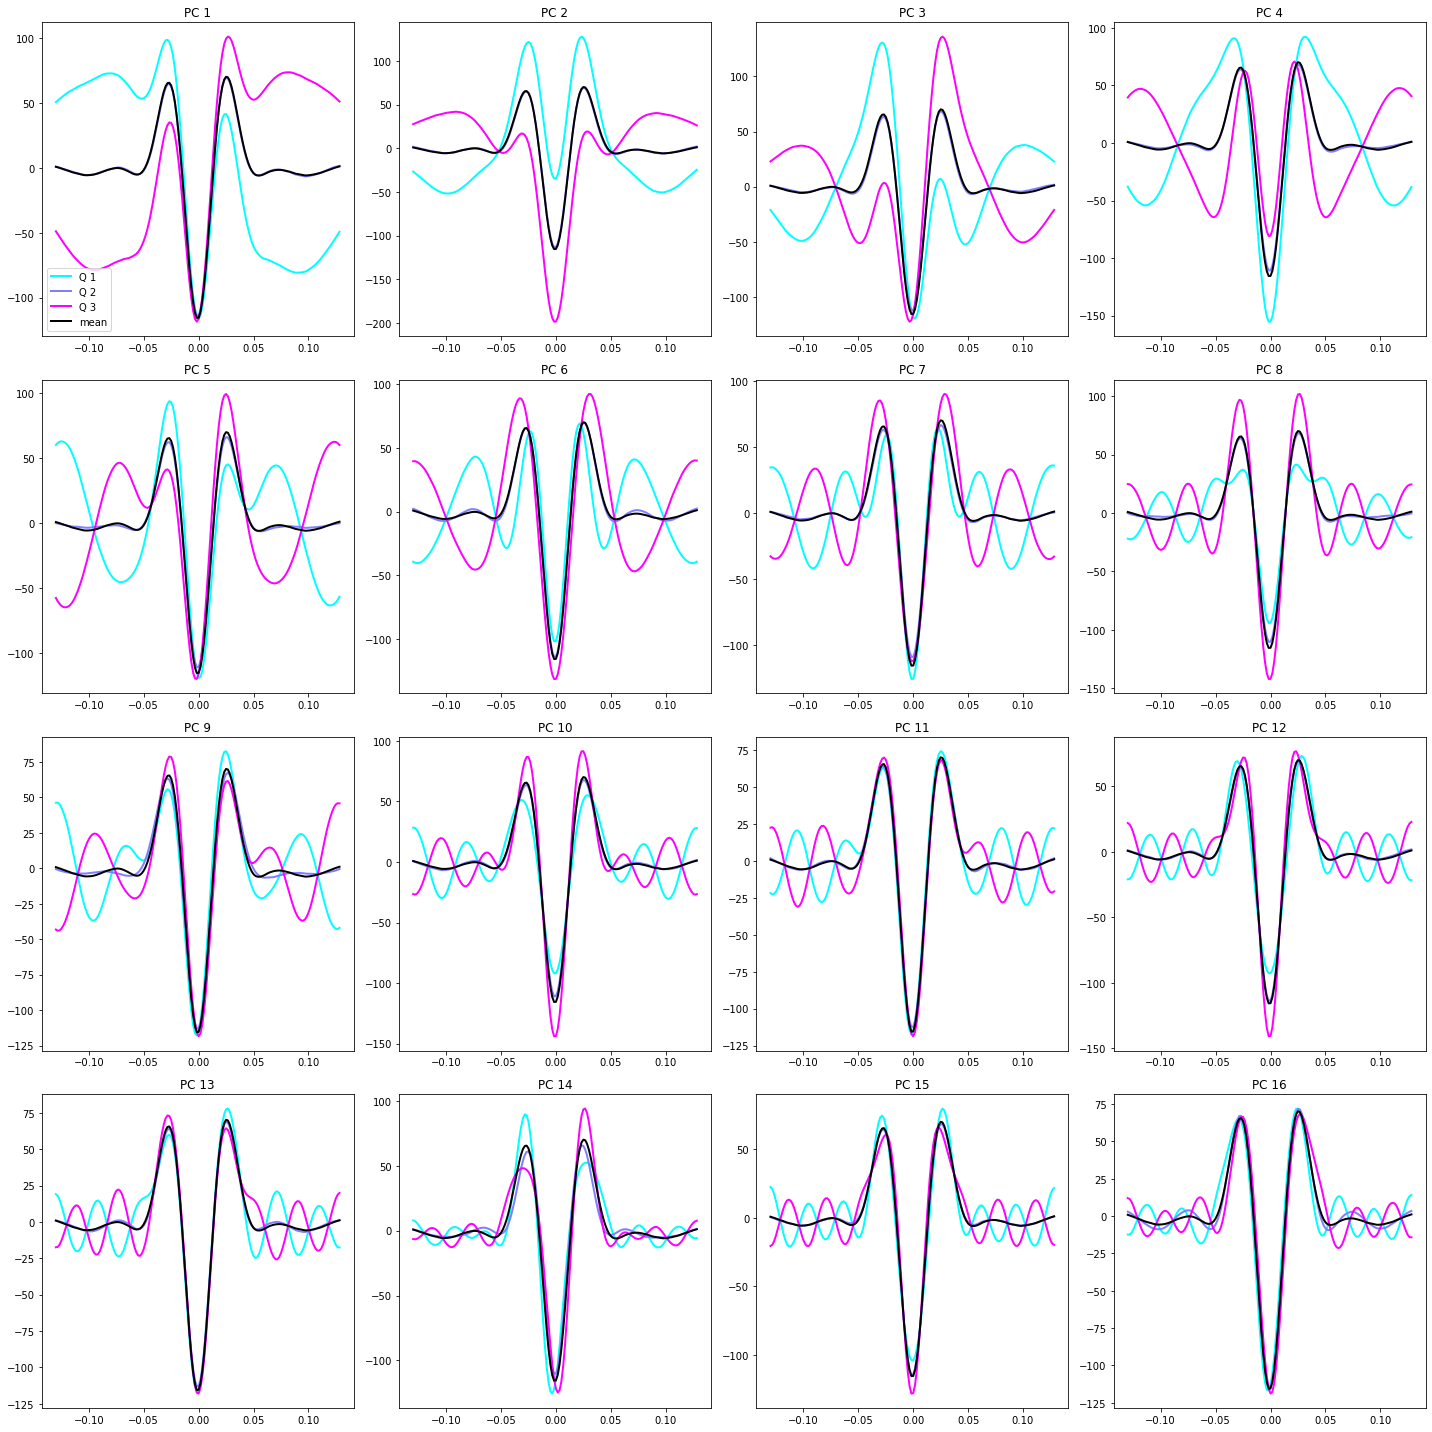

In [17]:
waveforms=all_bursts['waveform']
model = PCA(n_components=20)
burst_std=np.zeros(waveforms.shape)
for subject in np.unique(all_bursts['subject_id']):
    s_idx=all_bursts['subject_id']==subject
    burst_std[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
burst_std = RobustScaler().fit_transform(burst_std)
model.fit(burst_std)
pc_scores = model.transform(burst_std)  # all the bursts x 20 components
pc_labels = ["PC_{}".format(i+1) for i in range(pc_scores.shape[1])]

n_q=3
quartiles = np.linspace(0, 100, num=n_q+1)
quartiles = list(zip(quartiles[:-1], quartiles[1:]))
col_range = plt.cm.cool(np.linspace(0, 1, num=len(quartiles)))
mean_waveform = np.mean(waveforms, axis=0)

f, ax = plt.subplots(4, 4, figsize=(20, 20))
ax = ax.flatten()
for pc_ix, pc in enumerate(pc_labels[:len(shuffling_results)]):
    ax[pc_ix].set_title(pc.replace("_", " "))  # set the nice title
    scores = pc_scores[:,pc_ix]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax[pc_ix].plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax[pc_ix].plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")
ax[0].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)

subject_score_ts={
    epoch_type: {
        condition: [] for condition in condition_names
    } for epoch_type in epoch_types
}
for subject_id in subject_ids:
    for epoch_type in epoch_types:
        for condition in condition_names:
            b_idx=(all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type) & (all_bursts['condition']==condition)
            pc_score_ts=[]
            for t_idx in range(len(stim_time_bins)-1):
                st=stim_time_bins[t_idx]
                en=stim_time_bins[t_idx+1]
                bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
                ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
                pc_score_ts.append(ms)
            pc_score_ts=np.array(pc_score_ts)
            pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
            subject_score_ts[epoch_type][condition].append(pc_score_ts)

for epoch_type in epoch_types:
    for condition in condition_names:
        subject_score_ts[epoch_type][condition]=np.array(subject_score_ts[epoch_type][condition])

PC4 SHORT p=0.004999500049995001
PC4 LONG p=0.0007999200079992001


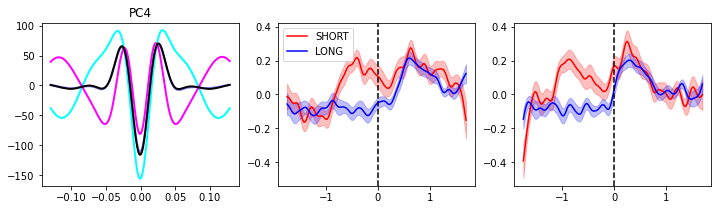

PC6 SHORT p=0.42525747425257476
PC6 LONG p=9.999000099990002e-05


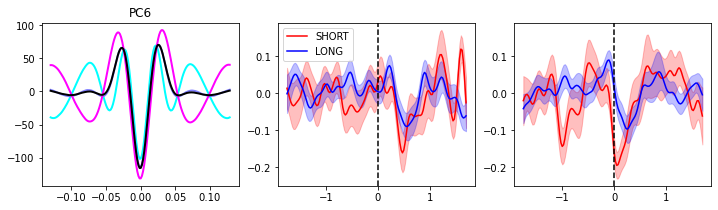

PC8 SHORT p=0.15028497150284972
PC8 LONG p=9.999000099990002e-05


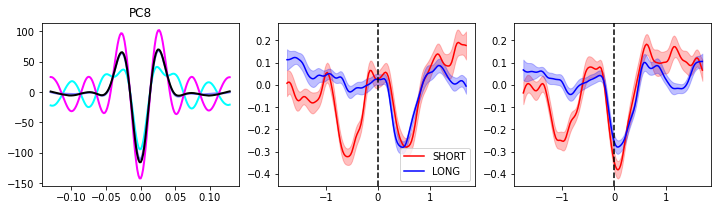

PC10 SHORT p=0.09809019098090191
PC10 LONG p=9.999000099990002e-05


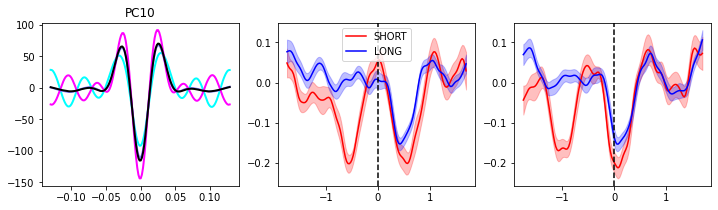

PC12 SHORT p=0.0504949505049495
PC12 LONG p=0.0006999300069993001


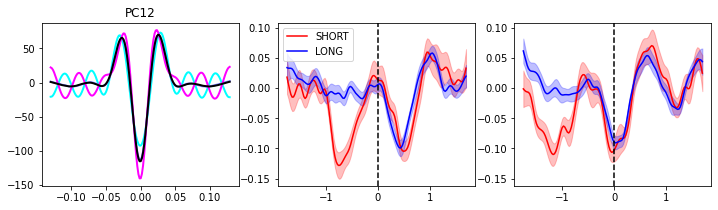

In [27]:
n_perm = 10000  # number of permutations

# Boolean mask for STIM baseline (pre-0)
stim_baseline_mask = (stim_time_bins[:-1] > -.5) & (stim_time_bins[:-1] < 0)
resp_mask = (resp_time_bins[:-1] > -.25) & (resp_time_bins[:-1] < .5)

task_pcs=[]

for pc in shuffling_results:
    m_stim_short = np.nanmean(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]
    se_stim_short = np.nanstd(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['SHORT'].shape[0])
    m_resp_short = np.nanmean(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]
    se_resp_short = np.nanstd(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['SHORT'].shape[0])
    
    m_stim_long = np.nanmean(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]
    se_stim_long = np.nanstd(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['LONG'].shape[0])
    m_resp_long = np.nanmean(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]
    se_resp_long = np.nanstd(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['LONG'].shape[0])
    
    # ------------------------------------------------------------------
    # Permutation test: is RESP temporal variance > STIM pre-0 variance?
    # ------------------------------------------------------------------
    stim_data_short = subject_score_ts['STIM']['SHORT'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_short = subject_score_ts['RESP']['SHORT'][:, :, pc]  # shape: n_subj × n_time_resp
    stim_data_long = subject_score_ts['STIM']['LONG'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_long = subject_score_ts['RESP']['LONG'][:, :, pc]  # shape: n_subj × n_time_resp

    # Per-subject temporal variances
    var_baseline_short = np.nanvar(stim_data_short[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_short = np.nanvar(resp_data_short[:, resp_mask], axis=1, ddof=1)
    var_baseline_long = np.nanvar(stim_data_long[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_long = np.nanvar(resp_data_long[:, resp_mask], axis=1, ddof=1)

    diff_short = var_resp_short - var_baseline_short              # ?_i
    diff_long = var_resp_long - var_baseline_long              # ?_i
    obs_stat_short = np.mean(diff_short)                    # observed mean difference across subjects
    obs_stat_long = np.mean(diff_long)                    # observed mean difference across subjects

    # Sign-flip permutation for paired test
    null_stats_short = np.zeros(n_perm)
    null_stats_long = np.zeros(n_perm)
    for p in range(n_perm):
        signs_short = np.random.choice([1, -1], size=diff_short.shape[0])
        signs_long = np.random.choice([1, -1], size=diff_long.shape[0])
        null_stats_short[p] = np.mean(diff_short * signs_short)
        null_stats_long[p] = np.mean(diff_long * signs_long)

    # One-sided p-value: H1 = RESP variance > baseline variance
    p_val_short = (np.sum(null_stats_short >= obs_stat_short) + 1) / (n_perm + 1)
    p_val_long = (np.sum(null_stats_long >= obs_stat_long) + 1) / (n_perm + 1)
    
    if p_val_short*len(shuffling_results)<0.05 or p_val_long*len(shuffling_results)<0.05:
        print(f'PC{pc+1} SHORT p={p_val_short}')
        print(f'PC{pc+1} LONG p={p_val_long}')
        task_pcs.append(pc)
        
        plt.figure(figsize=(12,3))

        ax=plt.subplot(1,3,1)
        ax.set_title(f'PC{pc+1}')  # set the nice title
        scores = pc_scores[:,pc]
        q_maps = []
        for q_ix, (b, e) in enumerate(quartiles):
            q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
            q_mean = np.mean(waveforms[q_map], axis=0)
            ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
        ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

        # STIM
        ax1 = plt.subplot(1,3,2)
        ax1.plot(stim_time_bins[:-1], m_stim_short, color='r', label='SHORT')
        ax1.fill_between(stim_time_bins[:-1], m_stim_short-se_stim_short, m_stim_short+se_stim_short, color='r', alpha=0.25)
        ax1.plot(stim_time_bins[:-1], m_stim_long, color='b', label='LONG')
        ax1.fill_between(stim_time_bins[:-1], m_stim_long-se_stim_long, m_stim_long+se_stim_long, color='b', alpha=0.25)
        ax1.axvline(0,color='k',linestyle='--')
        ax1.legend()
        yl1=ax1.get_ylim()

        # RESP
        ax2 = plt.subplot(1,3,3)
        ax2.plot(resp_time_bins[:-1], m_resp_short, color='r')
        ax2.fill_between(resp_time_bins[:-1], m_resp_short-se_resp_short, m_resp_short+se_resp_short, color='r', alpha=0.25)
        ax2.plot(resp_time_bins[:-1], m_resp_long, color='b')
        ax2.fill_between(resp_time_bins[:-1], m_resp_long-se_resp_long, m_resp_long+se_resp_long, color='b', alpha=0.25)
        ax2.axvline(0,color='k',linestyle='--')
        yl2=ax2.get_ylim()

        ymin=np.min([yl1[0], yl2[0]])
        ymax=np.max([yl1[1], yl2[1]])
        ax1.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)
        plt.show()

stat_fun(H1): min=-4.436206 max=3.329555
Running initial clustering …
Using 888 thresholds from 0.00 to 4.44 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.887304 max=6.415367
Running initial clustering …
Using 1284 thresholds from 0.00 to 6.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.311797 max=2.820695
Running initial clustering …
Using 565 thresholds from 0.00 to 2.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.273600 max=5.893845
Running initial clustering …
Using 1179 thresholds from 0.00 to 5.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.476563 max=3.379071
Running initial clustering …
Using 696 thresholds from 0.00 to 3.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

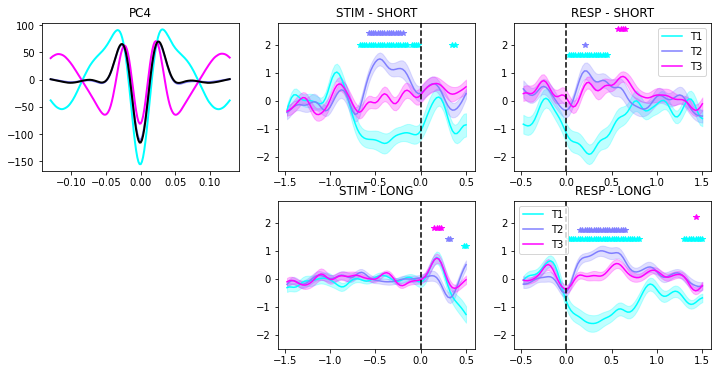

stat_fun(H1): min=-2.302555 max=2.293361
Running initial clustering …
Using 461 thresholds from 0.00 to 2.30 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.950902 max=3.460856
Running initial clustering …
Using 693 thresholds from 0.00 to 3.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.523253 max=2.502150
Running initial clustering …
Using 705 thresholds from 0.00 to 3.52 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.034287 max=2.249337
Running initial clustering …
Using 807 thresholds from 0.00 to 4.03 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.869733 max=4.582037
Running initial clustering …
Using 917 thresholds from 0.00 to 4.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

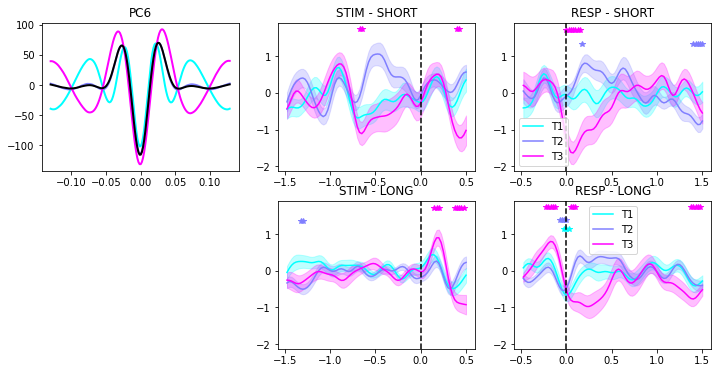

stat_fun(H1): min=-2.128296 max=4.213028
Running initial clustering …
Using 843 thresholds from 0.00 to 4.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.762542 max=3.901668
Running initial clustering …
Using 781 thresholds from 0.00 to 3.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.477492 max=2.156343
Running initial clustering …
Using 1696 thresholds from 0.00 to 8.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.336283 max=4.342419
Running initial clustering …
Using 869 thresholds from 0.00 to 4.34 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.957481 max=3.007235
Running initial clustering …
Using 1792 thresholds from 0.00 to 8.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

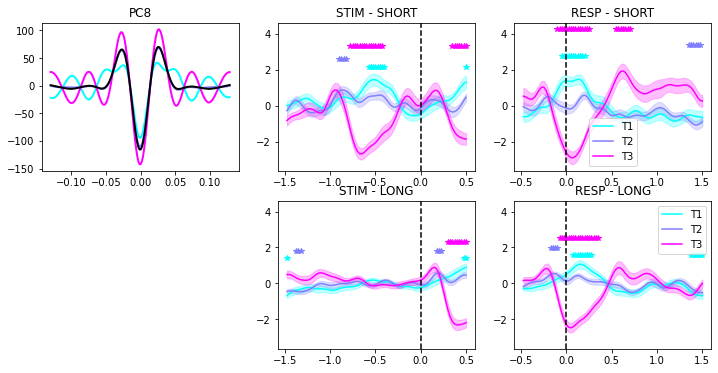

stat_fun(H1): min=-2.712522 max=4.404058
Running initial clustering …
Using 881 thresholds from 0.00 to 4.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.900235 max=3.159872
Running initial clustering …
Using 632 thresholds from 0.00 to 3.16 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.638741 max=1.815396
Running initial clustering …
Using 1528 thresholds from 0.00 to 7.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.053148 max=4.070714
Running initial clustering …
Using 1011 thresholds from 0.00 to 5.05 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.194301 max=3.603274
Running initial clustering …
Using 1639 thresholds from 0.00 to 8.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

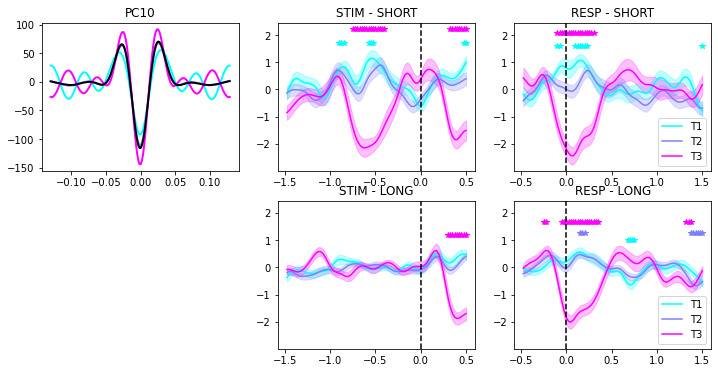

stat_fun(H1): min=-2.402109 max=4.662890
Running initial clustering …
Using 933 thresholds from 0.00 to 4.66 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.528556 max=3.570564
Running initial clustering …
Using 715 thresholds from 0.00 to 3.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.097562 max=2.040637
Running initial clustering …
Using 1420 thresholds from 0.00 to 7.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.668288 max=4.537612
Running initial clustering …
Using 1134 thresholds from 0.00 to 5.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.704532 max=3.582042
Running initial clustering …
Using 1541 thresholds from 0.00 to 7.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

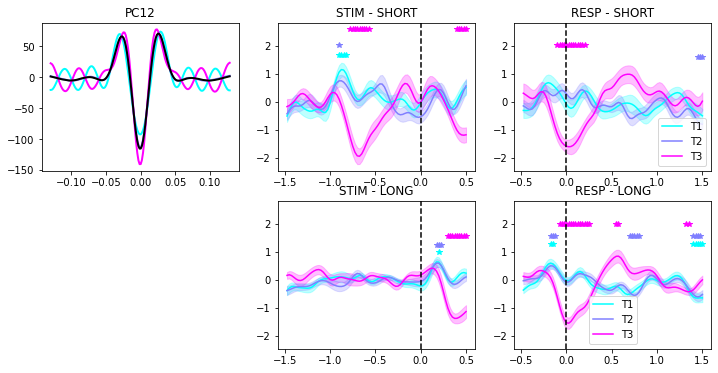

In [35]:
step = 100 / n_q
stim_plt_idx=(stim_time_bins[:-1]>=-1.5) & (stim_time_bins[:-1]<=.5)
resp_plt_idx=(resp_time_bins[:-1]>=-.5) & (resp_time_bins[:-1]<=1.5)

stim_time_plt=stim_time_bins[:-1][stim_plt_idx]
resp_time_plt=resp_time_bins[:-1][resp_plt_idx]

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {
        q: {
            epoch_type: {
                condition: [] for condition in condition_names
            } for epoch_type in epoch_types
        } for q in range(n_q)
    }
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx
        resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            
            stim_short_idx = stim_b_idx & (all_bursts['condition']=='SHORT')
            resp_short_idx = resp_b_idx & (all_bursts['condition']=='SHORT')
            stim_long_idx = stim_b_idx & (all_bursts['condition']=='LONG')
            resp_long_idx = resp_b_idx & (all_bursts['condition']=='LONG')
            
            stim_short_trials = np.unique(all_bursts['trial'][stim_short_idx])
            resp_short_trials = np.unique(all_bursts['trial'][resp_short_idx])
            stim_long_trials = np.unique(all_bursts['trial'][stim_long_idx])
            resp_long_trials = np.unique(all_bursts['trial'][resp_long_idx])

            stim_short_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_short_idx & q_idx],
                bins=stim_time_bins
            )
            resp_short_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_short_idx & q_idx],
                bins=resp_time_bins
            )
            stim_long_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_long_idx & q_idx],
                bins=stim_time_bins
            )
            resp_long_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_long_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            stim_short_unsmoothed_rate = (stim_short_unsmoothed_rate / bin_width) / len(stim_short_trials)
            resp_short_unsmoothed_rate = (resp_short_unsmoothed_rate / bin_width) / len(resp_short_trials)
            stim_long_unsmoothed_rate = (stim_long_unsmoothed_rate / bin_width) / len(stim_long_trials)
            resp_long_unsmoothed_rate = (resp_long_unsmoothed_rate / bin_width) / len(resp_long_trials)

            stim_short_smoothed_rate = gaussian_filter1d(stim_short_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_short_smoothed_rate = gaussian_filter1d(resp_short_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            stim_long_smoothed_rate = gaussian_filter1d(stim_long_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_long_smoothed_rate = gaussian_filter1d(resp_long_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-.75) & (stim_time_bins < -0.1))[0]
            base_rate = np.mean(stim_long_smoothed_rate[base_idx])

            stim_short_smoothed_rate = (stim_short_smoothed_rate - base_rate)[stim_plt_idx]
            resp_short_smoothed_rate = (resp_short_smoothed_rate - base_rate)[resp_plt_idx]
            stim_long_smoothed_rate = (stim_long_smoothed_rate - base_rate)[stim_plt_idx]
            resp_long_smoothed_rate = (resp_long_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['SHORT'].append(stim_short_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(resp_short_smoothed_rate)
            q_rates_smoothed[q]['STIM']['LONG'].append(stim_long_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(resp_long_smoothed_rate)
            
    plt.figure(figsize=(12,6))

    ax=plt.subplot(2,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(2,3,2)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM']['SHORT'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
    ax1.set_title('STIM - SHORT')         
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    # RESP
    ax2 = plt.subplot(2,3,3)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP']['SHORT'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax2.legend()
    ax2.set_title('RESP - SHORT')
    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()
    
    # STIM
    ax3 = plt.subplot(2,3,5)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
        ax3.plot(stim_time_plt, m_rate, color=col_range[q])
        ax3.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM']['LONG'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax3.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax3.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
    ax3.set_title('STIM - LONG')         
    ax3.axvline(0,color='k',linestyle='--')
    yl3=ax3.get_ylim()

    # RESP
    ax4 = plt.subplot(2,3,6)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
        ax4.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax4.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP']['LONG'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax4.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax4.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax4.legend()
    ax4.set_title('RESP - LONG')
    ax4.axvline(0,color='k',linestyle='--')
    yl4=ax4.get_ylim()

    ymin=np.min([yl1[0], yl2[0], yl3[0], yl4[0]])
    ymax=np.max([yl1[1], yl2[1], yl3[0], yl4[0]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    ax3.set_ylim(ymin, ymax)
    ax4.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-4.120409 max=4.369216
Running initial clustering …
Using 874 thresholds from 0.00 to 4.37 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.089602 max=3.014623
Running initial clustering …
Using 618 thresholds from 0.00 to 3.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.964716 max=2.078498
Running initial clustering …
Using 1193 thresholds from 0.00 to 5.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.636628 max=2.134207
Running initial clustering …
Using 528 thresholds from 0.00 to 2.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.134716 max=0.884450
Running initial clustering …
Using 427 thresholds from 0.00 to 2.13 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

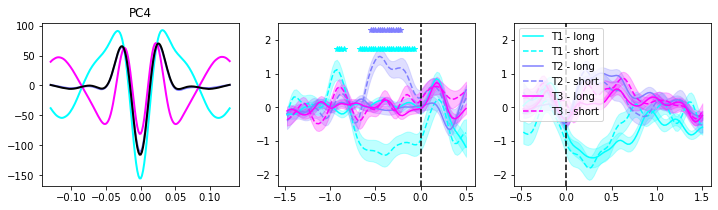

stat_fun(H1): min=-1.867019 max=2.692703
Running initial clustering …
Using 539 thresholds from 0.00 to 2.69 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.345239 max=1.904751
Running initial clustering …
Using 470 thresholds from 0.00 to 2.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.655172 max=2.581724
Running initial clustering …
Using 732 thresholds from 0.00 to 3.66 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.461273 max=3.292933
Running initial clustering …
Using 693 thresholds from 0.00 to 3.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.409302 max=2.694906
Running initial clustering …
Using 682 thresholds from 0.00 to 3.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

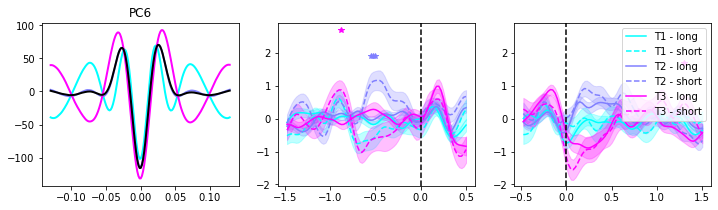

stat_fun(H1): min=-3.479464 max=0.968332
Running initial clustering …
Using 696 thresholds from 0.00 to 3.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.779375 max=2.945841
Running initial clustering …
Using 590 thresholds from 0.00 to 2.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.563297 max=2.015326
Running initial clustering …
Using 713 thresholds from 0.00 to 3.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.386086 max=8.250259
Running initial clustering …
Using 1651 thresholds from 0.00 to 8.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.560133 max=1.803181
Running initial clustering …
Using 913 thresholds from 0.00 to 4.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

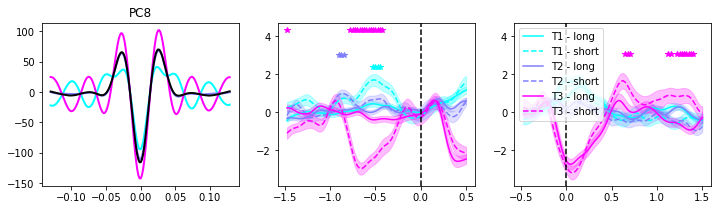

stat_fun(H1): min=-4.126969 max=2.010973
Running initial clustering …
Using 826 thresholds from 0.00 to 4.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.562958 max=1.018103
Running initial clustering …
Using 513 thresholds from 0.00 to 2.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.619757 max=2.007547
Running initial clustering …
Using 524 thresholds from 0.00 to 2.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.002661 max=6.815287
Running initial clustering …
Using 1364 thresholds from 0.00 to 6.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.939019 max=2.666645
Running initial clustering …
Using 534 thresholds from 0.00 to 2.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

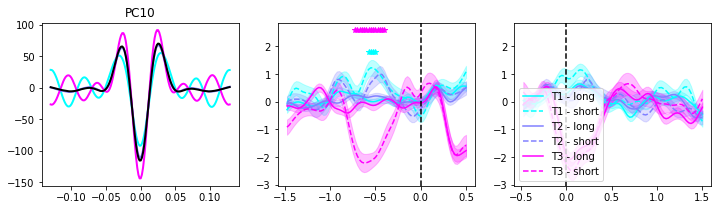

stat_fun(H1): min=-4.092990 max=1.343421
Running initial clustering …
Using 819 thresholds from 0.00 to 4.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.957012 max=1.754204
Running initial clustering …
Using 392 thresholds from 0.00 to 1.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.817274 max=1.802010
Running initial clustering …
Using 764 thresholds from 0.00 to 3.81 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.643075 max=5.873311
Running initial clustering …
Using 1175 thresholds from 0.00 to 5.87 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.228349 max=1.585186
Running initial clustering …
Using 446 thresholds from 0.00 to 2.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

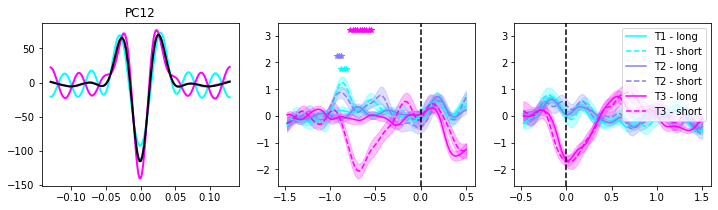

In [29]:
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins < -0.1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                 short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                 long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                 short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                 q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                 q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                 q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
        ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.1 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])


        m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
        ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        ax2.legend()
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.1 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()